## Main Equation:

$\frac{d^2 x}{dt^2} + \delta \frac{dx}{dt} + \alpha x + \beta x^3 = \gamma cos(\omega t)$

 - $\delta$ controls the amount of damping

- $\alpha$ controls the linear stiffness

- $\beta $ controls the amount of non-linearity in the restoring force

    - If $\beta$ = 0, the Duffing equation describes a damped and driven simple harmonic oscillator

- $\gamma$ is the amplitude of the periodic driving force
    - if $\gamma$ = 0, the system is without a driving force

- $\omega$ is the angular frequency of the periodic driving force.

Keeping $x_1$ as position, $x_2 = \frac{dx}{dt}$ as velocity. The system becomes:

$\frac{d x_1}{dt} = x_2$ and

$\frac{d x_2}{dt} = -\delta x_2 - \alpha x_1 - \beta x_1^3 + \gamma cos(\omega t)$

In [1]:
import numpy as np
import seaborn as sns
from scipy import constants
from scipy.integrate import solve_ivp

import matplotlib.pyplot as plt
from time import time


In [2]:
def duffing_forced_damped_sys(t : float, X : np.array, 
            alpha : float, beta : float, gamma : float, delta : float, omega : float):
    x1,x2 = X
    dx1dt = x2
    dx2dt = - (delta * x2 + alpha * x1 + beta * x1**3) + gamma * np.cos(omega * t)
    return np.array([dx1dt, dx2dt])

## Solution, phase portrait, time series

In [3]:
#soln
def generate_duffing_solution(X0, freq : float, t_span : np.array, alpha : float, beta : float, gamma : float, delta : float, omega : float, verbose = False):
    start_time = time()
    t_start, t_end = t_span[0], t_span[1]
    t = np.linspace(t_span[0], t_span[1], int((freq+1) * (t_end - t_start)))

    sol = solve_ivp(
        duffing_forced_damped_sys,
        t_span,
        X0,
        t_eval=t,
        args = (alpha, beta, gamma, delta, omega,),
        dense_output = True
    )

    x1 = sol.y[0]
    x2 = sol.y[1]
    end_time = time()
    if verbose:
        print(f"{end_time-start_time} seconds to generate soln.")
    return x1, x2, sol.t, sol

#plots

def time_series(x1, x2, sol_t):
    plt.plot(sol_t, x1, label="Disp")
    plt.plot(sol_t, x2, label="Vel")
    plt.title("Displacement vs Time")
    plt.xlabel("Time (t)")
    plt.ylabel("Displacement (x)")
    plt.legend()
    plt.grid()
    plt.tight_layout()

def phase_portrait(x1, x2):
    plt.figure(figsize=(6, 6))
    plt.axis('equal')
    plt.plot(x1, x2, 'b', lw=0.5)
    plt.title("Phase Portrait")
    plt.xlabel("x")
    plt.ylabel("v")
    plt.plot(x1[0], x2[0], 'go', label="Sim Start")
    plt.plot(x1[-1], x2[-1], 'ro', label="Sim End")
    plt.tight_layout()
    plt.legend()

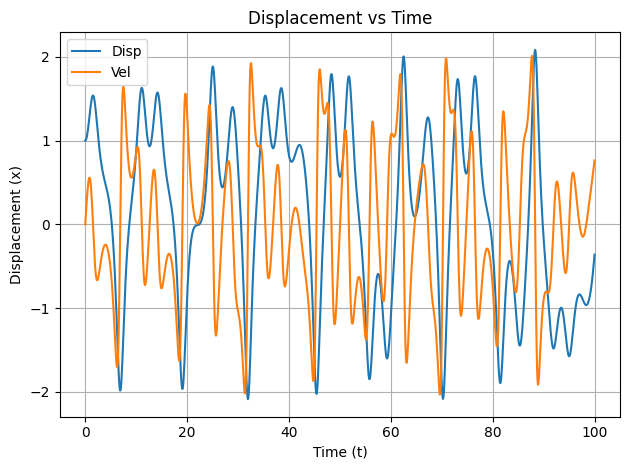

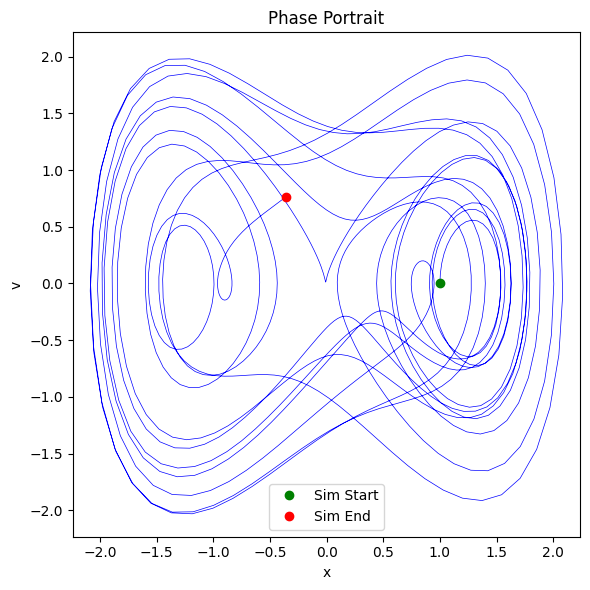

In [ ]:
delta = 0.1
alpha = -1
beta = 1.0
gamma = 1
omega = 0.5

X0 = np.array([1,0])
t_start = 0
t_end = 100
freq = 10 #number of timesteps per integral timestep (timesteps/second if si units)
t_span = np.array([t_start,t_end])

x1, x2, sol_t, _ = generate_duffing_solution(X0, freq, t_span, alpha, beta, gamma, delta, omega)
time_series(x1, x2, sol_t)
phase_portrait(x1, x2)


##  Poincaré section/map

In [ ]:
def poincare_section(sol, omega, save=True, res_index = 10):
    """
    Sample the solution at multiples of the driving period T = 2π/ω.
    """
    T = 2 * np.pi / omega
    #skip first 20%
    t_start = sol.t[0] + 0.2 * (sol.t[-1] - sol.t[0])
    t_end   = sol.t[-1]

    #list of stroboscopic sample times
    n_start = int(np.ceil((t_start - sol.t[0]) / T))
    n_end   = int(np.floor((t_end   - sol.t[0]) / T))
    sample_times = sol.t[0] + np.arange(n_start, n_end + 1) * T

    states = sol.sol(sample_times)  #2xN
    px = states[0]
    pv = states[1]

    plt.figure(figsize=(6, 6))
    plt.scatter(px, pv, c='navy', alpha=0.6, linewidths=0, s = 0.1/res_index)
    plt.title(f"Poincaré Section (Van Der Pol)  (T = 2π/ω, ω = {omega})")
    plt.xlabel("x")
    plt.ylabel("ẋ")
    plt.grid(True, lw=0.4)
    plt.tight_layout()

    if save:
        plt.savefig("output.png", dpi=100*res_index, bbox_inches='tight')

    return px, pv

906.550194978714 seconds to generate soln.


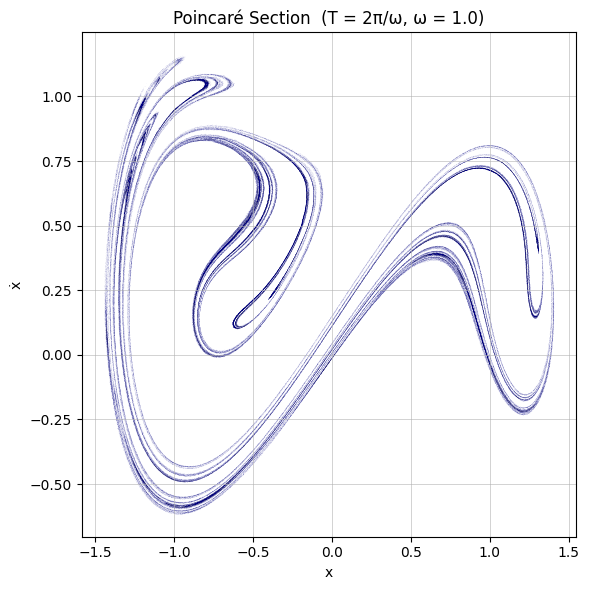

In [26]:
t_span = np.array([0,5_000_000])
gamma = 0.3
delta = 0.15
omega = 1.0

start_time = time()
x1, x2, sol_t, sol = generate_duffing_solution(X0, freq, t_span, alpha, beta, gamma, delta, omega, verbose=True)
# time_series(x1, x2, sol_t)
# phase_portrait(x1, x2)
px, pv = poincare_section(sol, omega)